# Ejercicio 2: PyTorch
### Tarea: Construye una red neuronal convolucional (CNN) usando PyTorch para clasificar las imágenes del dataset MNIST.


## 1. Importación de librerías

Primero importamos las librerías necesarias para trabajar con el dataset MNIST y construir el modelo de Perceptrón Multicapa (MLP).

In [ ]:
import torch
import torch.nn as nn # 
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import os
import random
from dataclasses import dataclass
from math import sqrt
from torch.utils.data import DataLoader, random_split

## 2. Configuración de parámetros

Configuramos los parámetros necesarios para entrenar nuestro modelo. Esto incluye el número de épocas, la tasa de aprendizaje, el tamaño del lote (batch size) y la semilla aleatoria para reproducibilidad.

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False # Desactiva la optimización de cuDNN para garantizar reproducibilidad


@dataclass
class Config:
    seed: int = 42
    batch_size: int = 128
    epochs: int = 5
    lr: float = 1e-3
    weight_decay: float = 0.0
    num_workers: int = 0
    val_split: int = 10_000
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config()
set_seed(cfg.seed)
print("Device:", cfg.device)


Device: cuda


## 3. Cálculo de desviación estándar y media de MNIST

Antes de cargar los datos y normalizarlos correctamente, es importante calcular la media y la desviación estándar del dataset MNIST. Esto nos permitirá normalizar los datos de manera adecuada, lo que puede mejorar el rendimiento del modelo.

Solo necesitamos el conjunto de entrenamiento para calcular la media y la desviación estándar.

In [3]:
transform = transforms.ToTensor() # Convierte la imagen PIL a un tensor de PyTorch y normaliza los valores a [0, 1]
dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True,
                                     transform=transform) 

loader = torch.utils.data.DataLoader(dataset, batch_size=1024, shuffle=False,
                                     num_workers=cfg.num_workers, pin_memory=(cfg.device=="cuda"))

mean = 0.0
std = 0.0
total_pixels = 0

for images, _ in loader: # cada images es un batch de imágenes, con forma (batch_size, channels, height, width)
    mean += images.sum() # suma de todos los valores de píxeles en el batch
    std += (images ** 2).sum() # suma de los cuadrados de los valores de píxeles en el batch
    
    total_pixels += images.numel() # Número total de píxeles procesados

mean /= total_pixels
std = sqrt(std / total_pixels - mean ** 2)

print(f"Mean: {mean}")
print(f"Std: {std}")

Mean: 0.13066047430038452
Std: 0.30810781438693347


## 4. Preparar Dataset y Dataloaders con Transformaciones Tensor y Normalización

Preparamos el dataset y los dataloaders para el entrenamiento y la evaluación del modelo. Aplicamos las transformaciones necesarias para convertir las imágenes a tensores de PyTorch y normalizarlas utilizando la media y desviación estándar calculadas previamente.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(), # Convierte la imagen PIL a un tensor de PyTorch y normaliza los valores a [0, 1]
    transforms.Normalize((mean,), (std,)) # Normaliza a media y desviación estándar calculadas
                                         # para centrar los datos alrededor de 0
])

train_full = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

#  train = train + val
val_size = cfg.val_split
train_size = len(train_full) - val_size
train_ds, val_ds = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(cfg.seed)
)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=(cfg.device=="cuda"))
val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=(cfg.device=="cuda"))
test_loader  = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=(cfg.device=="cuda"))

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 50000 | Val: 10000 | Test: 10000


## 3. Definición de arquitectura de la red

Definimos la arquitectura de la red neuronal convolucional (CNN) que utilizaremos para clasificar las imágenes del dataset MNIST. La arquitectura puede incluir varias capas convolucionales, capas de activación, capas de pooling y capas completamente conectadas.

In [5]:
class CNN_MNIST(nn.Module):
    """
    CNN sencilla y efectiva para MNIST.
    Estructura:
        - Conv2d(1, 16, kernel_size=3, padding=1) -> ReLU -> MaxPool2d(2, 2)
        - Conv2d(16, 32, kernel_size=3, padding=1) -> ReLU -> MaxPool2d(2, 2)
        - Flatten -> Linear(32*7*7, 128) -> ReLU -> Linear(128, 10)
    """
    def __init__(self):
        super(CNN_MNIST, self).__init__()
        # Capa Convolucional 1: entrada 1, salida 16, kernel 3x3
        # - Toma la imagen original (28x28) con pixeles en escala de grises (de ahí que solo necesitemos 1 canal)
        # extraemos 16 características simples p.ej: bordes, esquinas de la imagen original.
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        # Primera función de activación: ReLu - torna los valores negativos en 0 y mantiene los positivos
        self.relu1 = nn.ReLU()
        # Primera capa de pooling: MaxPool con kernel 2x2 y 2 pixeles de desplazamiento (stride)
        # - Reduce la dimensión espacial a la mitad (de 28x28 a 14x14)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Capa Convolucional 2: entrada 16, salida 32, kernel 3x3 
        # - Toma las 16 características extraídas en la capa anterior (14x14)
        # y extrae 32 nuevas características más complejas p.ej: combinaciones de bordes, formas, etc.
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # Segunda ReLu - torna los valores negativos en 0 y mantiene los positivos
        self.relu2 = nn.ReLU()
        # Segunda capa de pooling
        # - Reduce la dimensión espacial a la mitad (de 14x14 a 7x7)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Capa lineal (Totalmente conectada)
        # Con 128 neuronas ocultas
        # La imagen original es 28x28. Tras dos maxpools de 2x2, queda de 7x7, y con 32 canales (características) 
        # en la última capa convolucional
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        # Con 128 neuronas ocultas y 10 neuronas de salida (para las 10 clases de dígitos)
        self.fc2 = nn.Linear(128, 10) # 10 clases de salida (dígitos 0-9)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1) # Aplanar la salida convolucional, 
        # ya que la capa lineal espera un vector de características en lugar de una imagen 2D.
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

Aqui podemos visualizar la arquitectura de la red utilizando `torchsummary` para asegurarnos de que las dimensiones de las capas sean correctas.

In [6]:
model = CNN_MNIST()
print(model)

CNN_MNIST(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss() # Esta es la función de perdida para problemas de clasificación
optimizer = optim.Adam(model.parameters(), 
                        lr=cfg.lr, 
                        weight_decay=cfg.weight_decay
                       )

for epoch in range(cfg.epochs):
    model.train() # activa dropout - desactiva neuronas aleatoriamente durante el entrenamiento para evitar sobreajuste

    running_loss = 0.0 # Variable para acumular la pérdida y mostrar el promedio cada cierto número de pasos
    for i, (images, labels) in enumerate(train_loader):
        # Forward
        outputs = model(images) # El modelo toma un batch de imágenes y produce un batch de predicciones (logits)
        # para cada clase
        loss = criterion(outputs, labels)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        if (i+1) % 300 == 0:
            print(f"Epoch [{epoch+1}/{cfg.epochs}], Paso [{i+1}/{len(train_loader)}], Loss: {running_loss/300:.4f}")
            running_loss = 0.0

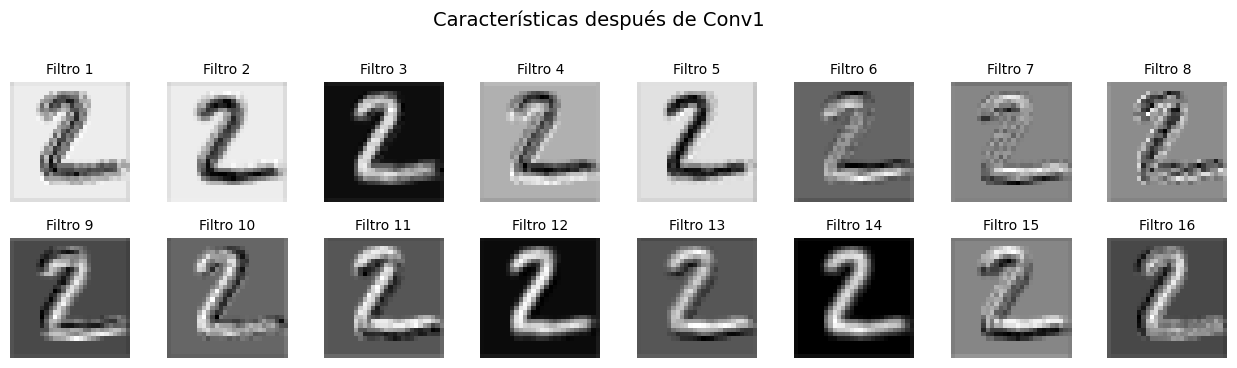

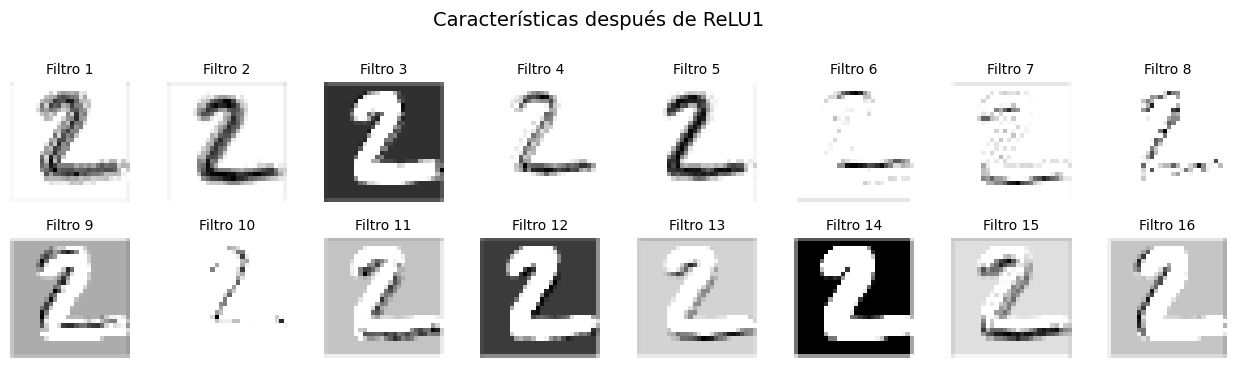

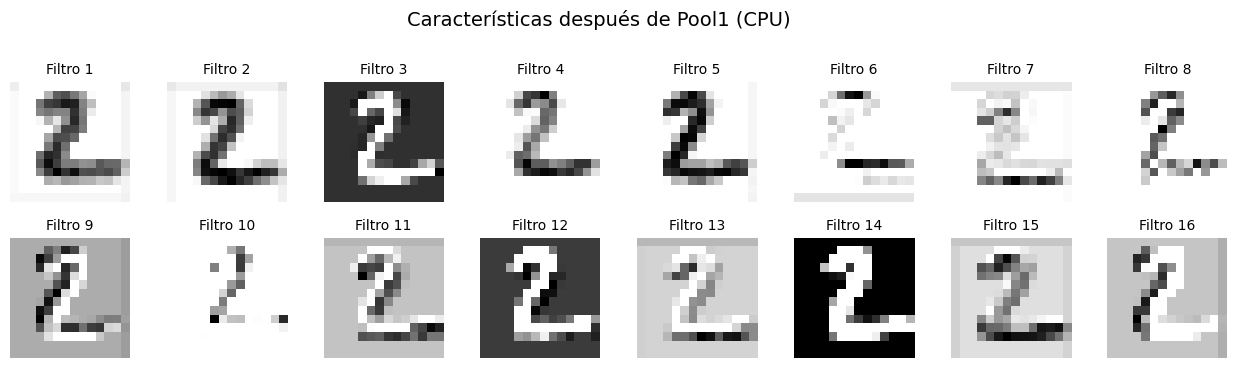

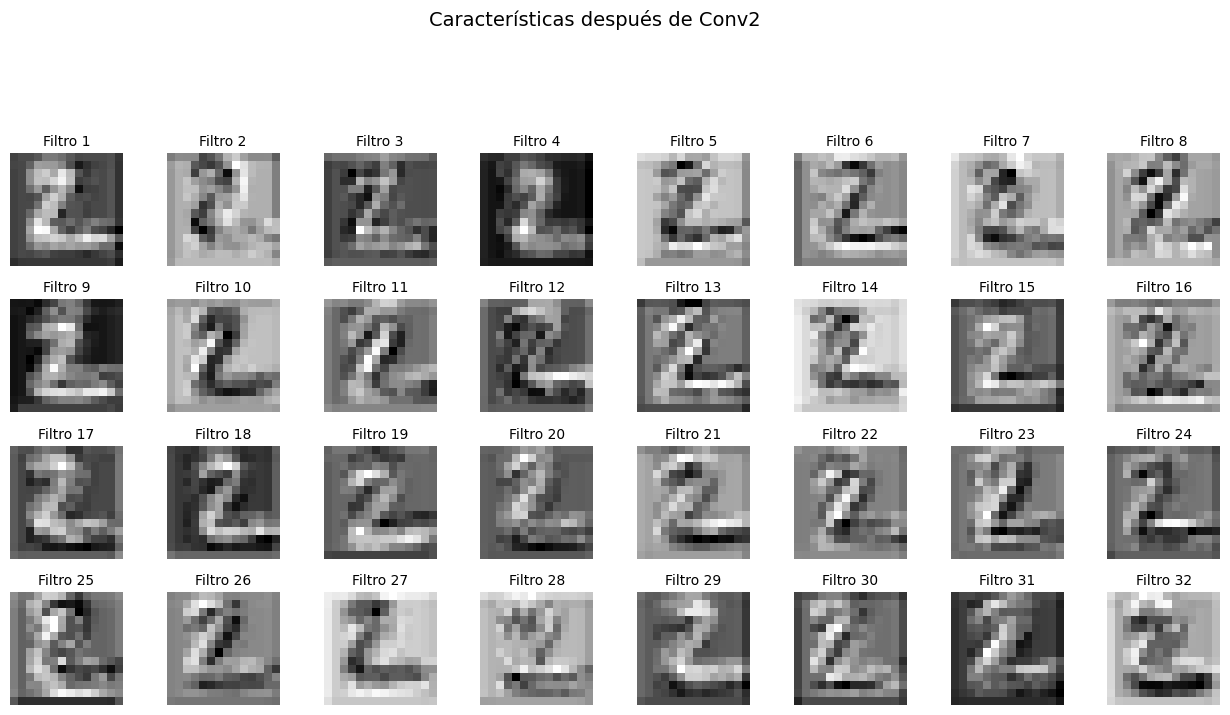

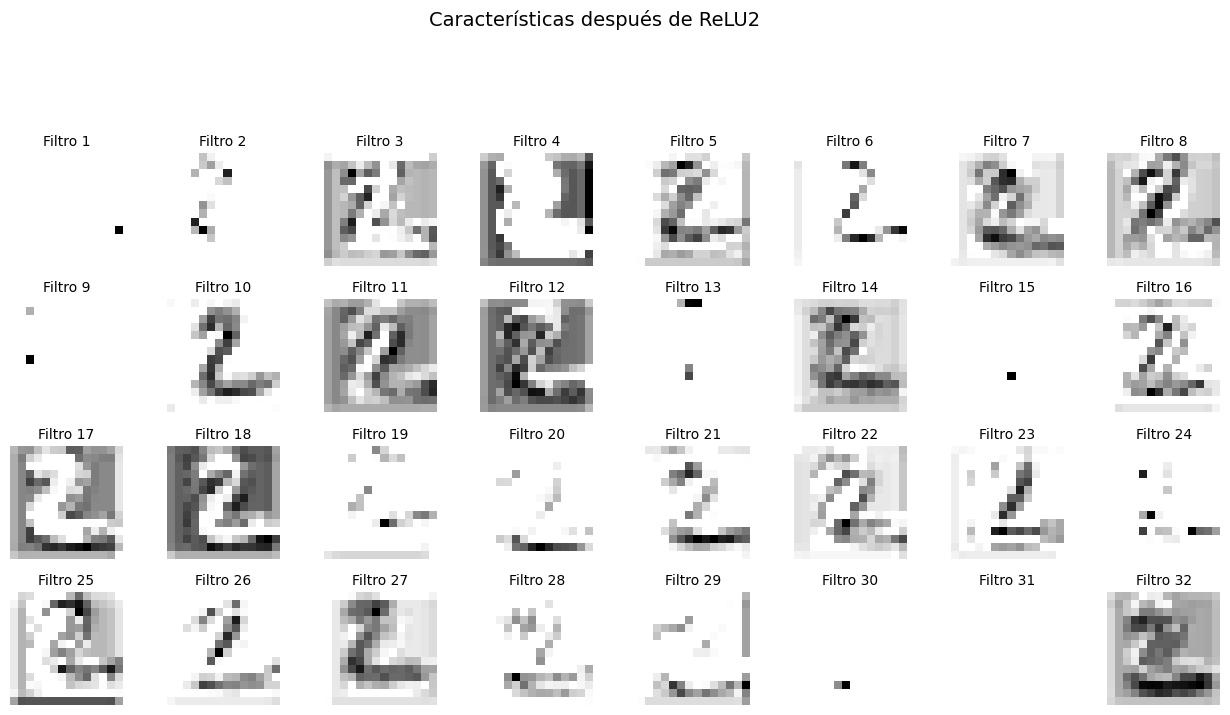

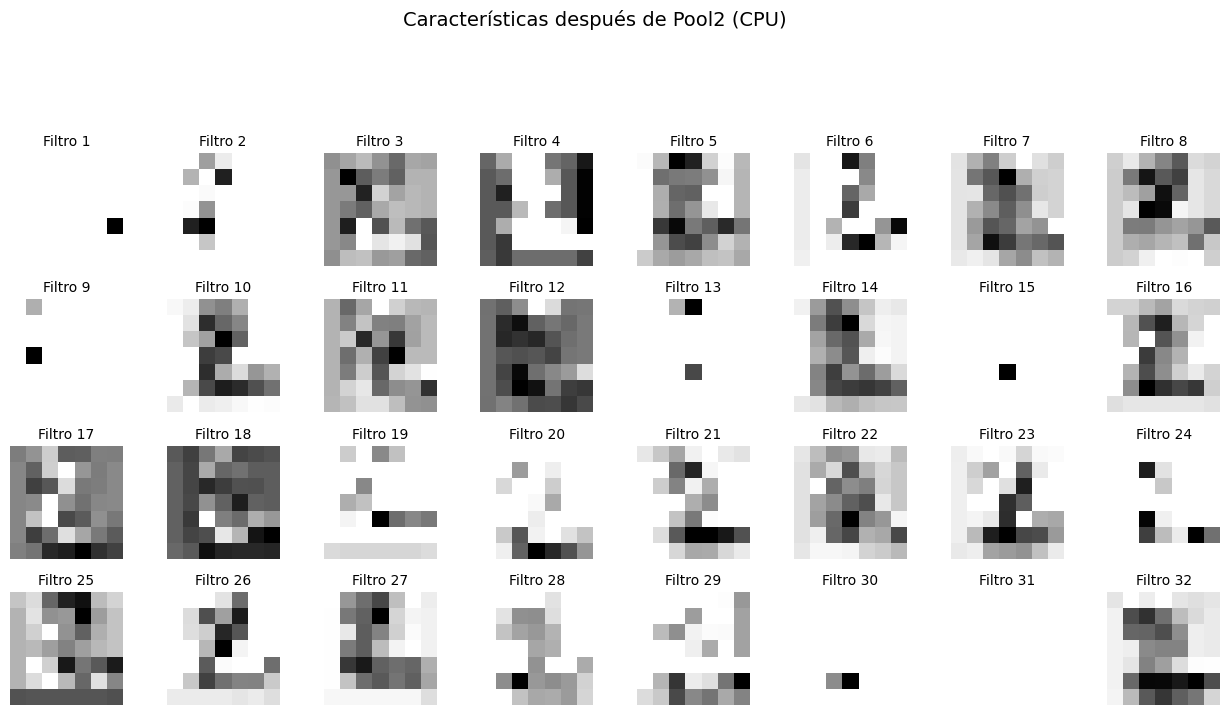

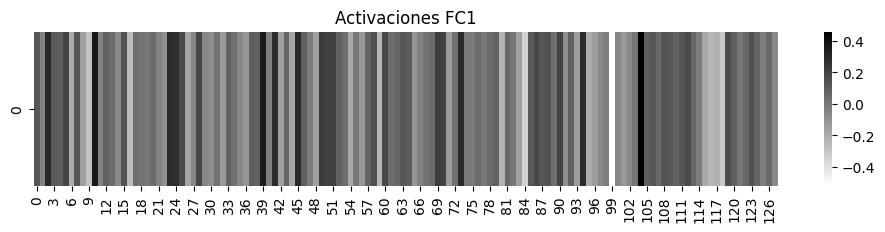

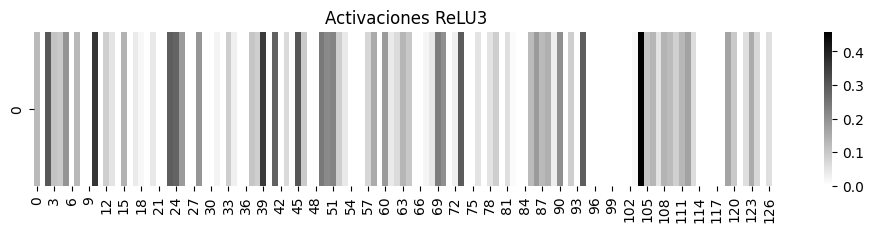

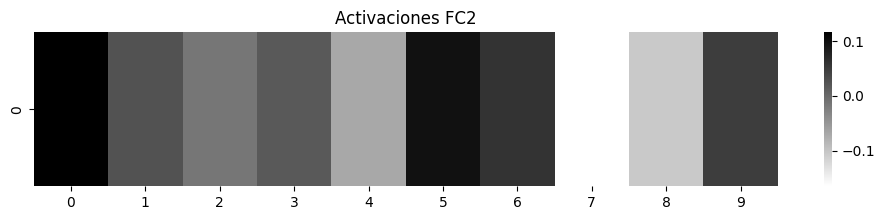

In [ ]:
def visualizar_caracteristicas(modelo, imagen_tensor, filename="pytorch_caracteristicas.png"):
    modelo.eval()
    with torch.no_grad():
        features = modelo.conv1(imagen_tensor.unsqueeze(0))
        plot_caracteristicas(features, filename, title="Características después de Conv1")
        features = modelo.relu1(features)
        plot_caracteristicas(features, filename, title="Características después de ReLU1")
        features = modelo.pool1(features)
        features = features.cpu()  # Mover a CPU para visualización con matplotlib
        plot_caracteristicas(features, filename, title="Características después de Pool1 (CPU)")
        features = modelo.conv2(features)
        plot_caracteristicas(features, filename, title="Características después de Conv2")
        features = modelo.relu2(features)
        plot_caracteristicas(features, filename, title="Características después de ReLU2")
        features = modelo.pool2(features)
        features = features.cpu()  # Mover a CPU para visualización con matplotlib
        plot_caracteristicas(features, filename, title="Características después de Pool2 (CPU)")
        # Flatten -> FC1 -> ReLU3
        flattened = features.view(features.size(0), -1)
        features = modelo.fc1(flattened)
        plot_fc_features(features, "fc1.png", "Activaciones FC1")

        features = modelo.relu3(features)
        plot_fc_features(features, "relu3.png", "Activaciones ReLU3")

        features = modelo.fc2(features)
        plot_fc_features(features, "fc2.png", "Activaciones FC2")

import seaborn as sns

def plot_fc_features(features, filename, title):
    features = features.squeeze(0).cpu().numpy()  # [num_neuronas]
    plt.figure(figsize=(12, 2))
    sns.heatmap(features[np.newaxis, :], cmap='binary', cbar=True)
    plt.title(title)
    plt.savefig(filename, dpi=300)
    plt.show()


def plot_caracteristicas(
    features, filename, title
):
    features = features.squeeze(0)  # [canales, H, W]
    num_canales = features.shape[0]

    # Crear subplots
    n_cols = 8
    n_rows = (num_canales + n_cols - 1) // n_cols  # ceil division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))
    
    axes = axes.flatten()  # para iterar fácilmente
    for i in range(num_canales):
        ax = axes[i]
        ax.imshow(features[i].cpu().numpy(), cmap='binary')
        ax.axis('off')
        ax.set_title(f"Filtro {i+1}", fontsize=10)

    # Ajuste final de layout
    plt.subplots_adjust(top=0.8, hspace=0.3, wspace=0.1)
    fig.suptitle(title, fontsize=14)
    
    plt.savefig(filename, dpi=300)
    plt.show()

__file__ = os.path.abspath("ejercicio_2_pytorch.ipynb")
# Visualización de características aprendidas por la primera capa convolucional
sample_img, _ = test_ds[1]
current_dir = os.path.dirname(os.path.abspath(__file__))
img_path = os.path.join(current_dir, 'pytorch_features.png')
visualizar_caracteristicas(model, sample_img, filename=img_path)

Definimos el criterio de pérdida (loss function) y el optimizador que utilizaremos para entrenar el modelo. En este caso, utilizamos la función de pérdida de entropía cruzada (CrossEntropyLoss) y el optimizador Adam.  

CrossEntropyLoss es una función de pérdida comúnmente utilizada para problemas de clasificación, ya que combina la función softmax con la función de pérdida de entropía cruzada.   
Softmax - Si el modelo produce las salidas [2.0, 1.0, 0.1], la función softmax las transformará en probabilidades como [0.7, 0.2, 0.1]. Tienen que sumar 1 y ser mayores que 0.  
Función de pérdida de entropía cruzada - Si la etiqueta verdadera es 0 (primera clase) y el modelo predice [0.7, 0.2, 0.1], la pérdida será baja porque el modelo está haciendo una buena predicción. Si el modelo predice [0.1, 0.2, 0.7], la pérdida será alta porque el modelo está haciendo una mala predicción.  

Adam es un optimizador eficiente que ajusta los pesos del modelo durante el entrenamiento, es muy comúnmente utilizado en redes neuronales debido a su capacidad para manejar grandes cantidades de datos y parámetros.

In [ ]:
# Evaluación
print("\nEvaluando modelo...")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
acc = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print(f"\nExactitud (Accuracy): {acc * 100:.2f}%")
print("Matriz de Confusión:")
print(cm)



Evaluando modelo...

Exactitud (Accuracy): 13.16%
Matriz de Confusión:
[[316   0   0   0   0  69 197   0   0 398]
 [670   0   2   0   0 215 240   0   0   8]
 [100   0   3   0   0  34 557   0   0 338]
 [162   0   0   0   0  58 482   0   0 308]
 [108   0   2   0   0  79 391   0   0 402]
 [329   1   0   1   0 113 152   0   0 296]
 [220   0   0   0   0  41 359   0   0 338]
 [145   0   0   0   0 282  78   0   0 523]
 [267   0   0   0   0 111 273   0   0 323]
 [226   0   0   0   0  72 186   0   0 525]]
